# Track 1 — Decision Quality Analysis

Analyses the Rule Engine regression report (`rule_engine_report.json`) to produce:
- Confusion matrix heatmap (`fig_01_confusion_matrix.png`)
- Per-class precision / recall / F1 table
- Per-nota decision distribution (`fig_02_decision_by_nota.png`)
- Missing-fields analysis for NON_DETERMINABILE cases

**Prerequisites:** `make eval-rule-engine` must have been run at least once.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("../..").resolve()
REPORT_PATH = ROOT / "evaluation" / "results" / "rule_engine_report.json"
FIG_DIR = ROOT / "evaluation" / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not REPORT_PATH.exists():
    print(f"ERROR: {REPORT_PATH} not found.")
    print("Run 'make eval-rule-engine' first.")
    sys.exit(0)

with open(REPORT_PATH, encoding="utf-8") as f:
    report = json.load(f)

print(f"Report timestamp: {report['timestamp']}")
print(f"Total cases: {report['total_cases']} | Passed: {report['passed']} | Failed: {report['failed']}")

Report timestamp: 2026-02-24T18:11:22.634089+00:00
Total cases: 37 | Passed: 37 | Failed: 0


In [2]:
# Build DataFrame from per-case results
rows = []
for r in report["results"]:
    rd = r["checks"].get("reimbursement_decision", {})
    nota = r["case_id"][:3]  # N97, N01, N13, N66
    rows.append({
        "case_id":  r["case_id"],
        "nota":     nota,
        "category": r.get("category", "unknown"),
        "expected": rd.get("expected") or "ROUTED",
        "actual":   rd.get("actual")   or "ROUTED",
        "pass":     r["pass"],
    })

df = pd.DataFrame(rows)
print(df.groupby(["nota", "expected"]).size().rename("count").reset_index())

  nota           expected  count
0  N01   NON_RIMBORSABILE      2
1  N01       RIMBORSABILE      5
2  N01             ROUTED      1
3  N13   NON_RIMBORSABILE      4
4  N13       RIMBORSABILE      4
5  N66   NON_RIMBORSABILE      5
6  N66       RIMBORSABILE      4
7  N97  NON_DETERMINABILE      2
8  N97   NON_RIMBORSABILE      5
9  N97       RIMBORSABILE      5


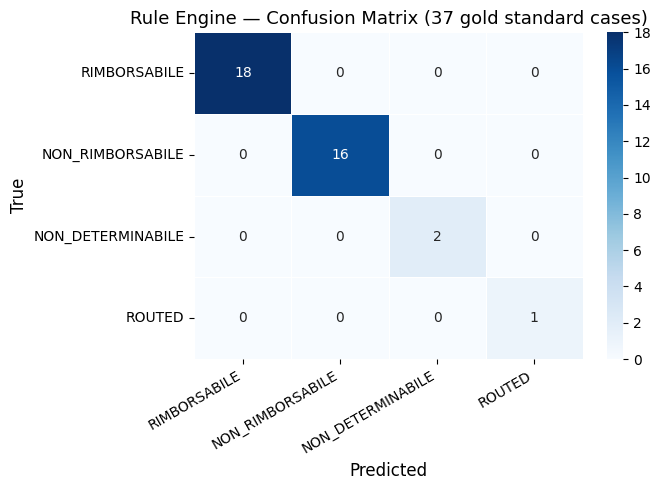

Saved fig_01_confusion_matrix.png


In [3]:
# Cell 3 — Confusion matrix heatmap
CLASSES = ["RIMBORSABILE", "NON_RIMBORSABILE", "NON_DETERMINABILE", "ROUTED"]
matrix_data = report.get("confusion_matrix", {})

cm = np.array([[matrix_data.get(r, {}).get(c, 0) for c in CLASSES] for r in CLASSES])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Rule Engine — Confusion Matrix (37 gold standard cases)", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_01_confusion_matrix.png", dpi=150)
plt.show()
print("Saved fig_01_confusion_matrix.png")

In [4]:
# Cell 4 — Per-class precision / recall / F1 table
pcm = report.get("per_class_metrics", {})
rows_metrics = []
for cls in CLASSES:
    m = pcm.get(cls, {})
    rows_metrics.append({
        "Class":     cls,
        "Precision": m.get("precision", 0),
        "Recall":    m.get("recall", 0),
        "F1":        m.get("f1", 0),
        "Support":   m.get("support", 0),
})
rows_metrics.append({
    "Class":     "Macro avg (excl. ROUTED)",
    "Precision": "",
    "Recall":    "",
    "F1":        pcm.get("macro_avg", {}).get("f1", ""),
    "Support":   "",
})

metrics_df = pd.DataFrame(rows_metrics).set_index("Class")
display(metrics_df.style.format({
    "Precision": lambda x: f"{x:.4f}" if isinstance(x, float) else x,
    "Recall":    lambda x: f"{x:.4f}" if isinstance(x, float) else x,
    "F1":        lambda x: f"{x:.4f}" if isinstance(x, float) else x,
}))

,Precision,Recall,F1,Support
Class,,,,
RIMBORSABILE,1.0000,1.0000,1.0000,18
NON_RIMBORSABILE,1.0000,1.0000,1.0000,16
NON_DETERMINABILE,1.0000,1.0000,1.0000,2
ROUTED,1.0000,1.0000,1.0000,1
Macro avg (excl. ROUTED),,,1.0000,


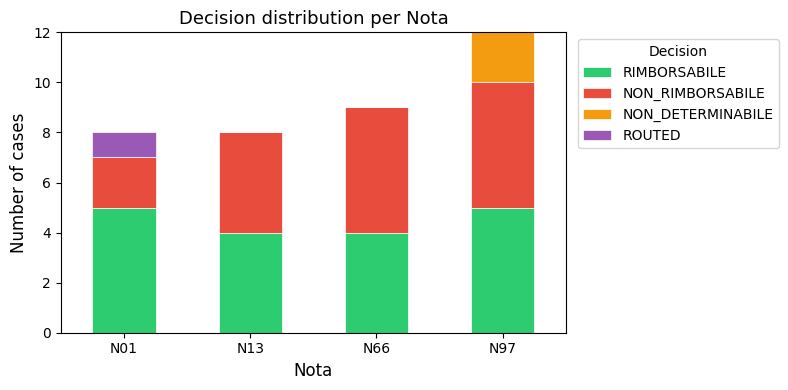

Saved fig_02_decision_by_nota.png


In [5]:
# Cell 5 — Per-nota decision distribution (stacked bar)
DECISION_COLORS = {
    "RIMBORSABILE":     "#2ecc71",
    "NON_RIMBORSABILE": "#e74c3c",
    "NON_DETERMINABILE":"#f39c12",
    "ROUTED":           "#9b59b6",
}

pivot = df.groupby(["nota", "expected"]).size().unstack(fill_value=0)
# Ensure all columns present
for col in CLASSES:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[CLASSES]

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=[DECISION_COLORS[c] for c in CLASSES],
           edgecolor="white", linewidth=0.5)
ax.set_xlabel("Nota", fontsize=12)
ax.set_ylabel("Number of cases", fontsize=12)
ax.set_title("Decision distribution per Nota", fontsize=13)
ax.legend(title="Decision", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_02_decision_by_nota.png", dpi=150)
plt.show()
print("Saved fig_02_decision_by_nota.png")

In [6]:
# Cell 6 — Missing fields analysis for NON_DETERMINABILE cases
nd_cases = [r for r in report["results"]
            if r["checks"].get("reimbursement_decision", {}).get("actual") == "NON_DETERMINABILE"]

print(f"NON_DETERMINABILE cases: {len(nd_cases)}")
for r in nd_cases:
    mf = r["checks"].get("missing_fields_coverage", {})
    print(f"  {r['case_id']}: {r['description'][:60]}")
    print(f"    missing fields: {mf.get('actual', [])}")

NON_DETERMINABILE cases: 2
  N97-008: NON_DETERMINABILE — Sex unknown, CHA2DS2-VASc range straddle
    missing fields: ['paziente_sesso']
  N97-009: NON_DETERMINABILE — Age/component unknown causing range [1,2
    missing fields: ['diabete_mellito']
